# EdgeAI-ZU4EV — Phase 1C: hls4ml HLS Synthesis

**Tool**: hls4ml 0.6.x (compatible with Vivado HLS 2020.1)  
**Target**: XCZU4EV-1SFVC784I — 88K LUT, 728 DSP, 252 BRAM  
**Interface**: AXI4-Stream (io_stream) @ 200 MHz  

**Install**:
```bash
pip install hls4ml[profiling] qkeras tensorflow==2.6.0
```

---

## 1. Imports

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import hls4ml

print(f'hls4ml version : {hls4ml.__version__}')
print(f'TensorFlow     : {tf.__version__}')

os.makedirs('../results', exist_ok=True)

# ── Vivado HLS 2020.1 path (update to match your installation) ──
# Vivado 2020.1 uses vivado_hls, NOT the new 'vitis_hls' binary
VIVADO_HLS_BIN = '/tools/Xilinx/Vivado/2020.1/bin/vivado_hls'
# Or set via environment variable:
# os.environ['PATH'] = '/tools/Xilinx/Vivado/2020.1/bin:' + os.environ['PATH']

WARN: Unable to import optimizer(s) from expr_templates.py: No module named 'sympy'


/home/atw/miniconda3/envs/edgeai_39/lib/python3.9/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)
/home/atw/miniconda3/envs/edgeai_39/lib/python3.9/site-packages/hls4ml/converters/__init__.py:36: UserWarning: WARNING: ONNX converter is not enabled!
  warnings.warn("WARNING: ONNX converter is not enabled!", stacklevel=1)


hls4ml version : 0.8.1
TensorFlow     : 2.6.0


## 2. Load QKeras Q6 Model (VGG-Lite 16/24/32)

In [2]:
from qkeras import QConv2D, QDense, QActivation, quantized_bits, quantized_relu

# Custom objects needed to deserialize QKeras model
custom_objs = {
    'QConv2D'       : QConv2D,
    'QDense'        : QDense,
    'QActivation'   : QActivation,
    'quantized_bits': quantized_bits,
    'quantized_relu': quantized_relu,
}

model = keras.models.load_model('model_int8_qkeras.h5', custom_objects=custom_objs)
model.summary()

print(f'\nInput  shape: {model.input_shape}')
print(f'Output shape: {model.output_shape}')

2026-05-21 13:59:55.260731: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 13:59:55.282402: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 13:59:55.283022: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 13:59:55.283417: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate

Model: "VGG_Lite_Q6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 32, 32, 3)]       0         
_________________________________________________________________
conv1a (QConv2D)             (None, 32, 32, 16)        432       
_________________________________________________________________
bn_conv1a (BatchNormalizatio (None, 32, 32, 16)        64        
_________________________________________________________________
relu_conv1a (QActivation)    (None, 32, 32, 16)        0         
_________________________________________________________________
conv1b (QConv2D)             (None, 32, 32, 16)        2304      
_________________________________________________________________
bn_conv1b (BatchNormalizatio (None, 32, 32, 16)        64        
_________________________________________________________________
relu_conv1b (QActivation)    (None, 32, 32, 16)        

## 3. hls4ml Configuration

Key parameters for Vivado 2020.1:

| Parameter | Value | Rationale |
|-----------|-------|----------|
| Backend | `'Vivado'` | Use Vivado HLS (2020.1 does NOT have Vitis HLS API) |
| Part | `xczu4ev-sfvc784-1-i` | Exact part string for XCZU4EV |
| Clock | 5 ns (200 MHz) | PL clock pl_clk0 |
| IOType | `'io_stream'` | Generates AXI4-Stream ports for DMA |
| ReuseFactor | 64 | VGG-Lite 16/24/32 (~28K) on XCZU4EV |
| Strategy | `'Resource'` | Minimize parallel hardware; fits 88K LUT target |

In [3]:
# ── Step 1: Auto-generate default config from model ──
hls_config = hls4ml.utils.config_from_keras_model(
    model,
    granularity='name'
)

# ── Step 2: Global defaults ──
# Model default must be wide enough for result_t (10 logits); 8,3 truncates head output.
hls_config['Model']['Precision']    = 'ap_fixed<16,8>'
hls_config['Model']['ReuseFactor']  = 288
hls_config['Model']['Strategy']     = 'Resource'
hls_config['Model']['FifoDepth']    = 2
hls_config['Model']['BramFactor']   = 1000000

# Per-layer RF — must be a valid divisor of (filt_h*filt_w*cin*cout)
# For 16/20/24 student model (current, ~67% LUT, expected Q6 ~80%):
#   conv1a: 3*3*3*16=432    → RF=432  (1 mult)
#   conv1b: 3*3*16*16=2304  → RF=2304 (1 mult)
#   conv2a: 3*3*16*20=2880  → RF=2880 (1 mult)
#   conv2b: 3*3*20*20=3600  → RF=3600 (1 mult)
#   conv3a: 3*3*20*24=4320  → RF=4320 (1 mult)
#   conv3b: 3*3*24*24=5184  → RF=5184 (1 mult)
#   predictions: 24*10=240  → RF=240  (1 mult)
RF_PER_LAYER = {
    'conv1a': 432,
    'conv1b': 2304,
    'conv2a': 2880,
    'conv2b': 3600,
    'conv3a': 4320,
    'conv3b': 5184,
    'predictions': 240,
}
# Auto-detect actual RF from model layer shapes (Conv2D: 4-D; Dense: 2-D)
def _layer_ops(layer):
    k = layer.kernel.shape
    if len(k) == 4:        # Conv2D: kH * kW * cin * cout
        return int(k[0]) * int(k[1]) * int(k[2]) * int(k[3])
    elif len(k) == 2:      # Dense: in * out
        return int(k[0]) * int(k[1])
    return None

for layer in model.layers:
    if not hasattr(layer, 'kernel'):
        continue
    lname = layer.name
    ops = _layer_ops(layer)
    if ops is None:
        continue
    if lname not in RF_PER_LAYER:
        # Default: largest divisor <= ops (== ops itself) → 1 parallel mult
        RF_PER_LAYER[lname] = ops
    rf = RF_PER_LAYER[lname]
    if ops % rf != 0:
        # Snap down to nearest valid divisor
        for divisor in range(min(rf, ops), 0, -1):
            if ops % divisor == 0:
                RF_PER_LAYER[lname] = divisor
                print(f'RF adjusted: {lname} {rf} -> {divisor} (ops={ops})')
                break

print('RF per layer:', RF_PER_LAYER)

# ── Precision dicts ──
# accum: ap_fixed<8,3> (was <10,4>) — narrower accumulator saves ~15% MAC LUT
# BN scale/bias: ap_fixed<8,3> (was ap_fixed<16,6> default due to naming bug) — saves BN mult LUT
PREC_CONV = {
    'weight': 'ap_fixed<6,1>',
    'bias':   'ap_fixed<6,2>',
    'result': 'ap_fixed<6,3>',
    'accum':  'ap_fixed<8,3>',
}
PREC_DENSE = {
    'weight': 'ap_fixed<6,1>',
    'bias':   'ap_fixed<6,2>',
    'result': 'ap_fixed<8,3>',
    'accum':  'ap_fixed<8,3>',
}
PREC_BN = {
    'scale':  'ap_fixed<8,3>',
    'bias':   'ap_fixed<8,3>',
    'result': 'ap_fixed<6,3>',
}
PREC_ACT = {
    'result': 'ap_fixed<6,3>',
}
# Head (GAP + predictions): raised precision — csim 10%->60%, board demo 3/3 after re-bit
PREC_HEAD = {
    'weight': 'ap_fixed<16,8>',
    'bias':   'ap_fixed<16,8>',
    'result': 'ap_fixed<16,8>',
    'accum':  'ap_fixed<16,8>',
}

# ── Step 3: Per-layer overrides ──
# IMPORTANT: check BN/ReLU BEFORE 'conv', because 'bn_conv1a' contains the
# substring 'conv' and would otherwise be mis-classified as a Conv layer.
for layer in model.layers:
    lname = layer.name
    low = lname.lower()
    if 'bn_' in low or ('batch' in low and 'norm' in low):
        # BatchNorm — correct field names: scale / bias / result (NOT weight/accum)
        hls_config['LayerName'].setdefault(lname, {})
        hls_config['LayerName'][lname]['Precision'] = dict(PREC_BN)
    elif 'relu' in low or 'activation' in low:
        hls_config['LayerName'].setdefault(lname, {})
        hls_config['LayerName'][lname]['Precision'] = dict(PREC_ACT)
    elif 'softmax' in low:
        # Softmax stays but with narrow tables
        hls_config['LayerName'].setdefault(lname, {})
        hls_config['LayerName'][lname]['Precision'] = {
            'exp_table_t': 'ap_fixed<8,3>',
            'inv_table_t': 'ap_fixed<8,3>',
            'result':      'ap_fixed<8,3>',
        }
    elif 'conv' in low and 'dense' not in low:
        hls_config['LayerName'][lname] = {
            'Precision':    dict(PREC_CONV),
            'ReuseFactor':  RF_PER_LAYER.get(lname, 288),
            'Strategy':     'Resource',
        }
    elif lname == 'gap':
        hls_config['LayerName'][lname] = {
            'Precision':    dict(PREC_HEAD),
            'Strategy':     'Resource',
        }
    elif 'dense' in low or 'predictions' in low:
        hls_config['LayerName'][lname] = {
            'Precision':    dict(PREC_HEAD),
            'ReuseFactor':  RF_PER_LAYER.get(lname, 32),
            'Strategy':     'Resource',
        }

# ── Step 4: catch-all for pool / gap / pad / flatten ──
for lname in list(hls_config['LayerName'].keys()):
    lconf = hls_config['LayerName'][lname]
    low = lname.lower()
    has_full_prec = isinstance(lconf.get('Precision'), dict) and 'weight' in lconf['Precision']
    if has_full_prec:
        continue
    if 'pool' in low or 'pad' in low or 'flatten' in low:
        lconf['Precision'] = {'result': 'ap_fixed<8,3>'}
    elif lconf.get('Precision') in (None, {}):
        lconf['Precision'] = 'ap_fixed<8,3>'

# ── Step 5: ensure head layers keep high precision (override Step 4 defaults) ──
# Note: convert uses model_hls with output layer predictions_logits (softmax stripped).
for lname in ('gap', 'predictions', 'predictions_logits'):
    hls_config['LayerName'].setdefault(lname, {})
    hls_config['LayerName'][lname]['Precision'] = dict(PREC_HEAD)
    if lname == 'predictions_logits':
        hls_config['LayerName'][lname]['Strategy'] = 'Latency'
        hls_config['LayerName'][lname]['ReuseFactor'] = 1
    elif lname in RF_PER_LAYER:
        hls_config['LayerName'][lname]['ReuseFactor'] = RF_PER_LAYER[lname]
        hls_config['LayerName'][lname]['Strategy'] = 'Resource'

print('HLS Configuration:')
print(json.dumps(hls_config, indent=2, default=str))

Interpreting Model
Topology:
Layer name: input_image, layer type: InputLayer, input shapes: [[None, 32, 32, 3]], output shape: [None, 32, 32, 3]
Layer name: conv1a, layer type: QConv2D, input shapes: [[None, 32, 32, 3]], output shape: [None, 32, 32, 16]
Layer name: bn_conv1a, layer type: BatchNormalization, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: relu_conv1a, layer type: Activation, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: conv1b, layer type: QConv2D, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: bn_conv1b, layer type: BatchNormalization, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: relu_conv1b, layer type: Activation, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: pool1, layer type: MaxPooling2D, input shapes: [[None, 32, 32, 16]], output shape: [None, 16, 16, 16]
Layer name: conv2a, layer type: QConv2

### FIFO 深度工具（第 4、5、6 节共用）

运行本节一次即可；`compile()` / `convert` 每次写 firmware 后都要再调用 `cap_fifo_depths()`。


In [4]:
import re
from pathlib import Path

# hls4ml io_stream defaults FIFO depth = H*W per layer (e.g. 1024 at 32x32).
# cap_fifo_depths() must run after EVERY hls_model.compile() / convert write.
FIFO_DEPTH_CAP = 2

def cap_fifo_depths(hls_dir, cap=FIFO_DEPTH_CAP):
    fpath = Path(hls_dir) / 'firmware' / 'myproject.cpp'
    if not fpath.is_file():
        print(f'[FIFO cap] {fpath} not found, skipping')
        return 0
    txt = fpath.read_text(encoding='utf-8')
    pat = re.compile(r'(#pragma HLS STREAM\s+variable=\S+\s+depth=)(\d+)')
    n_changed = 0
    def repl(m):
        nonlocal n_changed
        d = int(m.group(2))
        if d > cap:
            n_changed += 1
            return f'{m.group(1)}{cap}'
        return m.group(0)
    new_txt = pat.sub(repl, txt)
    if n_changed:
        fpath.write_text(new_txt, encoding='utf-8')
    print(f'[FIFO cap] reduced {n_changed} stream pragmas to depth<={cap} in {fpath.name}')
    return n_changed

def verify_fifo_depths(hls_dir, max_depth=FIFO_DEPTH_CAP):
    fpath = Path(hls_dir) / 'firmware' / 'myproject.cpp'
    if not fpath.is_file():
        return True, []
    depths = [int(m.group(1)) for m in re.finditer(
        r'#pragma HLS STREAM\s+variable=\S+\s+depth=(\d+)', fpath.read_text(encoding='utf-8'))]
    bad = sorted({d for d in depths if d > max_depth})
    return len(bad) == 0, bad


## 4. Create hls4ml Project

In [5]:
import os
import re
import stat
import textwrap
from pathlib import Path
from hls4ml.model.optimizer import get_available_passes

HLS_OUTPUT_DIR = 'hls4ml_prj'
SYNTH_TOP_NAME = 'myproject_axi'
hls_output_path = Path(HLS_OUTPUT_DIR)

def make_tree_writable(root_path):
    root_path = Path(root_path)
    if not root_path.exists():
        return
    for current_root, dirnames, filenames in os.walk(root_path):
        os.chmod(current_root, stat.S_IRUSR | stat.S_IWUSR | stat.S_IXUSR)
        for dirname in dirnames:
            os.chmod(Path(current_root) / dirname, stat.S_IRUSR | stat.S_IWUSR | stat.S_IXUSR)
        for filename in filenames:
            os.chmod(Path(current_root) / filename, stat.S_IRUSR | stat.S_IWUSR)

def force_hls_export(build_script_path):
    build_script_path = Path(build_script_path)
    if not build_script_path.exists():
        return None, False

    script_text = build_script_path.read_text(encoding='utf-8')
    replaced = False
    if 'export     0' in script_text:
        script_text = script_text.replace('export     0', 'export     1', 1)
        replaced = True
    elif 'export 0' in script_text:
        script_text = script_text.replace('export 0', 'export 1', 1)
        replaced = True
    elif 'export     1' in script_text or 'export 1' in script_text:
        replaced = True

    build_script_path.write_text(script_text, encoding='utf-8')

    export_line = next((line.strip() for line in script_text.splitlines() if line.strip().startswith('export')), None)
    return export_line, replaced

def parse_output_layer_macro(defines_h_path):
    """Read hls4ml defines.h — output class count macro (e.g. N_LAYER_21 for 10 classes)."""
    text = Path(defines_h_path).read_text(encoding='utf-8')
    matches = re.findall(r'#define\s+(N_LAYER_\d+)\s+(\d+)', text)
    if not matches:
        raise RuntimeError(f'No N_LAYER_* macro in {defines_h_path}')
    for name, val in reversed(matches):
        if int(val) == 10:
            return name
    return matches[-1][0]

def write_single_stream_wrapper(output_dir):
    output_dir = Path(output_dir)
    firmware_dir = output_dir / 'firmware'
    firmware_dir.mkdir(parents=True, exist_ok=True)

    defines_h = firmware_dir / 'defines.h'
    if defines_h.exists():
        output_macro = parse_output_layer_macro(defines_h)
    else:
        output_macro = 'N_LAYER_21'
    print(f'AXIS wrapper output macro: {output_macro}')

    wrapper_header = textwrap.dedent('''
        #ifndef MYPROJECT_AXI_H_
        #define MYPROJECT_AXI_H_

        #include "ap_axi_sdata.h"
        #include "ap_fixed.h"
        #include "hls_stream.h"

        #include "defines.h"
        #include "myproject.h"

        typedef ap_axiu<16, 0, 0, 0> input_axi_t;
        typedef ap_axiu<16, 0, 0, 0> output_axi_t;

        void myproject_axi(
            hls::stream<input_axi_t> &input_stream,
            hls::stream<output_axi_t> &output_stream
        );

        #endif
    ''').strip() + '\n'

    wrapper_cpp = textwrap.dedent('''
        #include "myproject_axi.h"

        namespace {

        constexpr int kInputChannels = N_INPUT_3_1;
        constexpr int kInputWords = N_INPUT_1_1 * N_INPUT_2_1 * N_INPUT_3_1;
        constexpr int kGroupedInputWords = kInputWords / kInputChannels;
        constexpr int kOutputWords = __OUTPUT_MACRO__;

        ap_fixed<16, 6> bits_to_fixed(ap_uint<16> bits) {
            ap_fixed<16, 6> value;
            value.range(15, 0) = bits;
            return value;
        }

        ap_uint<16> fixed_to_bits(ap_fixed<16, 6> value) {
            return value.range(15, 0);
        }

        void axis_to_model_stream(
            hls::stream<input_axi_t> &input_stream,
            hls::stream<input_t> &model_input
        ) {
            for (int word_index = 0; word_index < kGroupedInputWords; ++word_index) {
                #pragma HLS PIPELINE II=1
                input_t packet;
                for (int channel_index = 0; channel_index < kInputChannels; ++channel_index) {
                    input_axi_t axis_word = input_stream.read();
                    packet[channel_index] = bits_to_fixed(axis_word.data);
                }
                model_input.write(packet);
            }
        }

        void model_to_axis_stream(
            hls::stream<result_t> &model_output,
            hls::stream<output_axi_t> &output_stream
        ) {
            result_t packet = model_output.read();

            for (int word_index = 0; word_index < kOutputWords; ++word_index) {
                #pragma HLS PIPELINE II=1
                output_axi_t axis_word;
                axis_word.data = fixed_to_bits(packet[word_index]);
                axis_word.keep = -1;
                axis_word.strb = -1;
                axis_word.last = (word_index == (kOutputWords - 1)) ? 1 : 0;
                output_stream.write(axis_word);
            }
        }

        } // namespace

        void myproject_axi(
            hls::stream<input_axi_t> &input_stream,
            hls::stream<output_axi_t> &output_stream
        ) {
            #pragma HLS INTERFACE axis port=input_stream
            #pragma HLS INTERFACE axis port=output_stream
            #pragma HLS INTERFACE ap_ctrl_none port=return
            #pragma HLS DATAFLOW

            hls::stream<input_t> model_input("model_input");
            hls::stream<result_t> model_output("model_output");
            #pragma HLS STREAM variable=model_input depth=4
            #pragma HLS STREAM variable=model_output depth=2

            axis_to_model_stream(input_stream, model_input);
            myproject(model_input, model_output);
            model_to_axis_stream(model_output, output_stream);
        }
    ''').strip() + '\n'

    wrapper_tb = textwrap.dedent('''
        #include <fstream>
        #include <iostream>
        #include <sstream>
        #include <string>
        #include <vector>

        #include "firmware/myproject_axi.h"

        namespace {

        constexpr int kInputWords = N_INPUT_1_1 * N_INPUT_2_1 * N_INPUT_3_1;
        constexpr int kOutputWords = __OUTPUT_MACRO__;

        ap_uint<16> float_to_fixed_bits(float value) {
            ap_fixed<16, 6> fixed_value = value;
            return fixed_value.range(15, 0);
        }

        float fixed_bits_to_float(ap_uint<16> bits) {
            ap_fixed<16, 6> fixed_value;
            fixed_value.range(15, 0) = bits;
            return static_cast<float>(fixed_value);
        }

        std::vector<float> parse_line(const std::string &line) {
            std::vector<float> values;
            std::stringstream line_stream(line);
            float value = 0.0f;
            while (line_stream >> value) {
                values.push_back(value);
            }
            return values;
        }

        void write_input_stream(const std::vector<float> &values, hls::stream<input_axi_t> &input_stream) {
            for (int index = 0; index < kInputWords; ++index) {
                input_axi_t axis_word;
                axis_word.data = float_to_fixed_bits(values[index]);
                axis_word.keep = -1;
                axis_word.strb = -1;
                axis_word.last = (index == (kInputWords - 1)) ? 1 : 0;
                input_stream.write(axis_word);
            }
        }

        std::vector<float> collect_output_stream(hls::stream<output_axi_t> &output_stream) {
            std::vector<float> values;
            values.reserve(kOutputWords);
            for (int index = 0; index < kOutputWords; ++index) {
                output_axi_t axis_word = output_stream.read();
                values.push_back(fixed_bits_to_float(axis_word.data));
            }
            return values;
        }

        void write_output_values(const std::vector<float> &values, std::ostream &out_stream) {
            for (int index = 0; index < static_cast<int>(values.size()); ++index) {
                out_stream << values[index];
                if (index + 1 != static_cast<int>(values.size())) {
                    out_stream << ' ';
                }
            }
            out_stream << std::endl;
        }

        } // namespace

        int main() {
            std::ifstream input_file("tb_data/tb_input_features.dat");
            std::ifstream prediction_file("tb_data/tb_output_predictions.dat");

            #ifdef RTL_SIM
                std::string result_path = "tb_data/rtl_cosim_results.log";
            #else
                std::string result_path = "tb_data/csim_results.log";
            #endif

            std::ofstream result_file(result_path);
            std::string input_line;
            std::string prediction_line;
            int sample_index = 0;

            if (input_file.is_open() && prediction_file.is_open()) {
                while (std::getline(input_file, input_line) && std::getline(prediction_file, prediction_line)) {
                    if (sample_index % 5000 == 0) {
                        std::cout << "Processing input " << sample_index << std::endl;
                    }

                    std::vector<float> input_values = parse_line(input_line);
                    if (static_cast<int>(input_values.size()) != kInputWords) {
                        std::cerr << "Unexpected input width in testbench." << std::endl;
                        return 1;
                    }

                    hls::stream<input_axi_t> input_stream("input_stream");
                    hls::stream<output_axi_t> output_stream("output_stream");
                    write_input_stream(input_values, input_stream);
                    myproject_axi(input_stream, output_stream);
                    std::vector<float> outputs = collect_output_stream(output_stream);
                    write_output_values(outputs, result_file);
                    sample_index++;
                }
            } else {
                std::cout << "INFO: Unable to open input/predictions file, using zero input." << std::endl;
                std::vector<float> input_values(kInputWords, 0.0f);
                hls::stream<input_axi_t> input_stream("input_stream");
                hls::stream<output_axi_t> output_stream("output_stream");
                write_input_stream(input_values, input_stream);
                myproject_axi(input_stream, output_stream);
                std::vector<float> outputs = collect_output_stream(output_stream);
                write_output_values(outputs, std::cout);
                write_output_values(outputs, result_file);
            }

            return 0;
        }
    ''').strip() + '\n'

    wrapper_cpp = wrapper_cpp.replace('__OUTPUT_MACRO__', output_macro)
    wrapper_tb = wrapper_tb.replace('__OUTPUT_MACRO__', output_macro)

    generated_files = {
        firmware_dir / 'myproject_axi.h': wrapper_header,
        firmware_dir / 'myproject_axi.cpp': wrapper_cpp,
        output_dir / 'myproject_axi_test.cpp': wrapper_tb,
    }

    for file_path, file_text in generated_files.items():
        file_path.write_text(file_text, encoding='utf-8')

    return list(generated_files)

def patch_build_script_for_single_stream(build_script_path):
    build_script_path = Path(build_script_path)
    if not build_script_path.exists():
        return False, 'build_prj.tcl not found'

    script_text = build_script_path.read_text(encoding='utf-8')

    if 'set synth_top_name "${project_name}_axi"' not in script_text:
        anchor = "source [file join $tcldir project.tcl]\n"
        if anchor not in script_text:
            raise RuntimeError('Unable to locate project.tcl include in build_prj.tcl')
        script_text = script_text.replace(anchor, anchor + '\nset synth_top_name "${project_name}_axi"\n', 1)

    replacements = [
        ('regexp "$o=+(\\w+)" $arg unused opt($o)', 'regexp "^${o}=+(\\w+)$" $arg unused opt($o)'),
        ('set_top ${project_name}', 'set_top ${synth_top_name}'),
        (
            'add_files firmware/${project_name}.cpp -cflags "-std=c++0x"\nadd_files -tb ${project_name}_test.cpp -cflags "-std=c++0x"',
            'add_files firmware/${project_name}.cpp -cflags "-std=c++0x"\nadd_files firmware/${synth_top_name}.cpp -cflags "-std=c++0x"\nadd_files -tb ${synth_top_name}_test.cpp -cflags "-std=c++0x"'
        ),
        (
            'add_files -tb ${project_name}_test.cpp -cflags "-std=c++0x -DRTL_SIM"',
            'add_files -tb ${synth_top_name}_test.cpp -cflags "-std=c++0x -DRTL_SIM"'
        ),
    ]

    for old_text, new_text in replacements:
        if old_text in script_text:
            script_text = script_text.replace(old_text, new_text, 1)

    build_script_path.write_text(script_text, encoding='utf-8')
    return True, 'single-stream export wrapper enabled'

if hls_output_path.exists():
    make_tree_writable(hls_output_path)

existing_build_script = hls_output_path / 'build_prj.tcl'
existing_export_line, _ = force_hls_export(existing_build_script)
if existing_export_line is not None:
    print(f'Existing build script export line: {existing_export_line}')
else:
    print('No existing build_prj.tcl found before conversion; continuing.')

# ── Build a logits-only model (no softmax) for HLS ──
# Softmax in HLS uses exp/inv lookup tables (~3-5K LUT). Since PS can do softmax
# trivially, we strip it here and let HLS output raw logits.
# The Dense layer itself is kept; only the softmax activation is removed.
import tensorflow as tf

_dense_lname = None
for _lyr in reversed(model.layers):
    if isinstance(_lyr, (tf.keras.layers.Dense,)) or 'dense' in _lyr.name.lower() or 'predictions' in _lyr.name.lower():
        _dense_lname = _lyr.name
        break

if _dense_lname is not None:
    _dense_lyr = model.get_layer(_dense_lname)
    _dense_w   = _dense_lyr.get_weights()
    _prev_out  = _dense_lyr.input
    _logits    = tf.keras.layers.Dense(
        _dense_lyr.units,
        activation='linear',
        name=_dense_lname + '_logits',
        use_bias=len(_dense_w) == 2,
    )(_prev_out)
    model_hls = tf.keras.Model(inputs=model.input, outputs=_logits, name=model.name + '_nosoftmax')
    model_hls.get_layer(_dense_lname + '_logits').set_weights(_dense_w)
    print(f'HLS model built without softmax. Output layer: {_dense_lname}_logits')
else:
    print('WARNING: could not find Dense/predictions layer; using original model (with softmax)')
    model_hls = model

hls_model = hls4ml.converters.convert_from_keras_model(
    model_hls,
    hls_config   = hls_config,
    output_dir   = HLS_OUTPUT_DIR,
    backend      = 'Vivado',
    part         = 'xczu4ev-sfvc784-1-i',
    clock_period = 5,
    io_type      = 'io_stream',
)

hls_model.write()


# ── Cap FIFO depths (utility defined in previous cell) ──
cap_fifo_depths(hls_output_path)
ok, bad_depths = verify_fifo_depths(hls_output_path)
if not ok:
    raise RuntimeError(f'FIFO depths still too large after cap: {bad_depths}')


generated_wrapper_files = write_single_stream_wrapper(hls_output_path)
build_script_path = hls_output_path / 'build_prj.tcl'
patch_ok, patch_msg = patch_build_script_for_single_stream(build_script_path)
export_line, _ = force_hls_export(build_script_path)

print(f'\nhls4ml project created at: {os.path.abspath(HLS_OUTPUT_DIR)}')
print(f'Wrapped HLS top       : {SYNTH_TOP_NAME}')
print(f'Build script path     : {build_script_path}')
print(f'Current export line   : {export_line if export_line is not None else "not generated yet"}')
print(f'Build script patch    : {patch_msg}')
print('Generated wrapper files:')
for file_path in generated_wrapper_files:
    print(f'  - {file_path}')
print('Contents:')
for root, dirs, files in os.walk(HLS_OUTPUT_DIR):
    level = root.replace(HLS_OUTPUT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files:
            print(f'{indent}  {f}')


No existing build_prj.tcl found before conversion; continuing.
HLS model built without softmax. Output layer: predictions_logits
Interpreting Model
Topology:
Layer name: input_image, layer type: InputLayer, input shapes: [[None, 32, 32, 3]], output shape: [None, 32, 32, 3]
Layer name: conv1a, layer type: QConv2D, input shapes: [[None, 32, 32, 3]], output shape: [None, 32, 32, 16]
Layer name: bn_conv1a, layer type: BatchNormalization, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: relu_conv1a, layer type: Activation, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: conv1b, layer type: QConv2D, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: bn_conv1b, layer type: BatchNormalization, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: relu_conv1b, layer type: Activation, input shapes: [[None, 32, 32, 16]], output shape: [None, 32, 32, 16]
Layer name: pool1, laye

Done
[FIFO cap] reduced 38 stream pragmas to depth<=2 in myproject.cpp
AXIS wrapper output macro: N_LAYER_29

hls4ml project created at: /home/atw/Edge_AI_Acc/claude/EdgeAI-ZU4EV_Claude/notebooks/hls4ml_prj
Wrapped HLS top       : myproject_axi
Build script path     : hls4ml_prj/build_prj.tcl
Current export line   : export     1
Build script patch    : single-stream export wrapper enabled
Generated wrapper files:
  - hls4ml_prj/firmware/myproject_axi.h
  - hls4ml_prj/firmware/myproject_axi.cpp
  - hls4ml_prj/myproject_axi_test.cpp
Contents:
hls4ml_prj/
  build_lib.sh
  project.tcl
  myproject_bridge.cpp
  myproject_test.cpp
  build_prj.tcl
  hls4ml_config.yml
  keras_model.h5
  myproject_axi_test.cpp
  vivado_synth.tcl
  firmware/
    myproject.cpp
    myproject.h
    defines.h
    myproject_axi.h
    parameters.h
    myproject_axi.cpp
    nnet_utils/
    ap_types/
      utils/
      etc/
    weights/
  tb_data/


## 5. C-Simulation (Functional Verification)

> **资源提示**：`hls_model.compile()` 会重新生成 `firmware/myproject.cpp`，恢复默认大 FIFO（depth=1024 等）。本节在 `compile()` 后自动调用 `cap_fifo_depths()`；第 6 节综合前会再次校验。


X_csim shape        : (100, 32, 32, 3)
X_csim dtype        : float32
C contiguous        : True
Writing HLS project


Done
[FIFO cap] reduced 38 stream pragmas to depth<=2 in myproject.cpp


2026-05-21 14:00:13.067773: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2026-05-21 14:00:15.787456: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8100
2026-05-21 14:00:19.460368: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-21 14:00:19.463236: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-21 14:00:19.463597: W tensorflow/stream_executor/gpu/asm_compiler.cc:77] Couldn't get ptxas version string: Internal: Couldn't invoke ptxas --version
2026-05-21 14:00:19.465073: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-21 14:00:19.465454: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] Internal: Failed to launch ptxas
Relying on driver to perform ptx co

C-Simulation Results (100 samples):
  HLS vs Keras Match  : 13.0%
  HLS  Accuracy       : 15.0%
  Keras Accuracy      : 84.0%


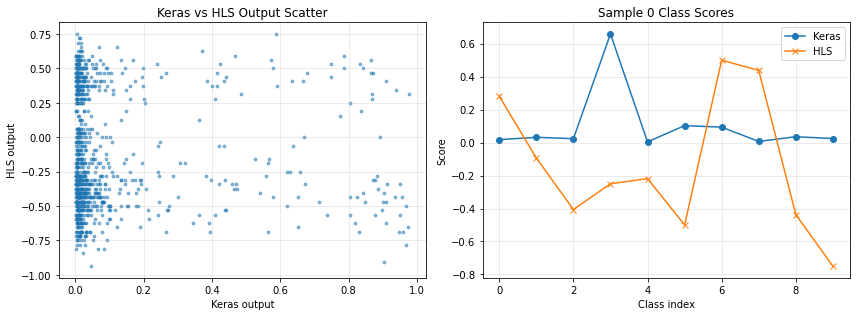

Saved: ../results/hls_vs_keras_predictions.png


In [6]:
# Load test data for C-sim
(_, _), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_test = np.ascontiguousarray(x_test.astype('float32') / 255.0)

# Use 100 test samples for C-simulation
X_csim = np.ascontiguousarray(x_test[:100])
y_true_csim = y_test[:100].flatten()

print(f'X_csim shape        : {X_csim.shape}')
print(f'X_csim dtype        : {X_csim.dtype}')
print(f'C contiguous        : {X_csim.flags["C_CONTIGUOUS"]}')

# compile() rewrites firmware/myproject.cpp with default FIFO depth=H*W.
# Without re-capping here, section 6 synthesis will use ~600+ BRAM again.
hls_model.compile()
_hls_prj = globals().get('hls_output_path', Path('hls4ml_prj'))
cap_fifo_depths(_hls_prj)
ok, bad_depths = verify_fifo_depths(_hls_prj)
if not ok:
    raise RuntimeError(
        f'Section 5: FIFO depths still {bad_depths} after cap. '
        'Run the FIFO utility cell (before section 4) then re-run this cell.'
    )

# Run C-simulation
y_hls = hls_model.predict(X_csim)
y_keras = model.predict(X_csim, verbose=0)

# Compare predictions
hls_pred = np.argmax(y_hls, axis=1)
keras_pred = np.argmax(y_keras, axis=1)

csim_match = np.mean(hls_pred == keras_pred) * 100
csim_accuracy = np.mean(hls_pred == y_true_csim) * 100
keras_accuracy = np.mean(keras_pred == y_true_csim) * 100

print(f'C-Simulation Results (100 samples):')
print(f'  HLS vs Keras Match  : {csim_match:.1f}%')
print(f'  HLS  Accuracy       : {csim_accuracy:.1f}%')
print(f'  Keras Accuracy      : {keras_accuracy:.1f}%')

comparison_path = '../results/hls_vs_keras_predictions.png'
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_keras.flatten(), y_hls.flatten(), s=8, alpha=0.5, color='#1f77b4')
axes[0].set_xlabel('Keras output')
axes[0].set_ylabel('HLS output')
axes[0].set_title('Keras vs HLS Output Scatter')
axes[0].grid(True, alpha=0.3)

sample_idx = 0
axes[1].plot(y_keras[sample_idx], label='Keras', marker='o')
axes[1].plot(y_hls[sample_idx], label='HLS', marker='x')
axes[1].set_title('Sample 0 Class Scores')
axes[1].set_xlabel('Class index')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(comparison_path, dpi=150)
plt.show()
print(f'Saved: {comparison_path}')


## 6. Run HLS Synthesis (Vivado HLS 2020.1)

> ⚠️ This cell runs `vivado_hls` — ensure it's in your PATH or update `VIVADO_HLS_BIN` above.  
> Synthesis typically takes 10–30 minutes for this model size.

In [7]:
import subprocess
import time

# Add Vivado 2020.1 to PATH for this session
vivado_bin_dir = os.path.dirname(VIVADO_HLS_BIN)
if vivado_bin_dir not in os.environ.get('PATH', ''):
    os.environ['PATH'] = vivado_bin_dir + ':' + os.environ.get('PATH', '')

build_script_path = Path(HLS_OUTPUT_DIR) / 'build_prj.tcl'
component_xml = hls_output_path / 'myproject_prj' / 'solution1' / 'impl' / 'ip' / 'component.xml'
expected_wrapper_files = [
    hls_output_path / 'firmware' / 'myproject_axi.h',
    hls_output_path / 'firmware' / 'myproject_axi.cpp',
    hls_output_path / 'myproject_axi_test.cpp',
]

def patch_build_script_for_single_stream_runtime(build_script_path):
    build_script_path = Path(build_script_path)
    if not build_script_path.exists():
        raise RuntimeError('build_prj.tcl not found. Please run code cell 4 first.')

    script_text = build_script_path.read_text(encoding='utf-8')

    if 'set synth_top_name "${project_name}_axi"' not in script_text:
        anchor = 'source [file join $tcldir project.tcl]\n'
        if anchor not in script_text:
            raise RuntimeError('Unable to locate project.tcl include in build_prj.tcl')
        script_text = script_text.replace(anchor, anchor + '\nset synth_top_name "${project_name}_axi"\n', 1)

    replacements = [
        ('regexp "$o=+(\\w+)" $arg unused opt($o)', 'regexp "^${o}=+(\\w+)$" $arg unused opt($o)'),
        ('set_top ${project_name}', 'set_top ${synth_top_name}'),
        (
            'add_files firmware/${project_name}.cpp -cflags "-std=c++0x"\nadd_files -tb ${project_name}_test.cpp -cflags "-std=c++0x"',
            'add_files firmware/${project_name}.cpp -cflags "-std=c++0x"\nadd_files firmware/${synth_top_name}.cpp -cflags "-std=c++0x"\nadd_files -tb ${synth_top_name}_test.cpp -cflags "-std=c++0x"'
        ),
        (
            'add_files -tb ${project_name}_test.cpp -cflags "-std=c++0x -DRTL_SIM"',
            'add_files -tb ${synth_top_name}_test.cpp -cflags "-std=c++0x -DRTL_SIM"'
        ),
    ]

    for old_text, new_text in replacements:
        if old_text in script_text:
            script_text = script_text.replace(old_text, new_text, 1)

    if 'export     0' in script_text:
        script_text = script_text.replace('export     0', 'export     1', 1)
    elif 'export 0' in script_text:
        script_text = script_text.replace('export 0', 'export 1', 1)

    build_script_path.write_text(script_text, encoding='utf-8')
    return script_text

# If code cell 4 has been run in this kernel, regenerate wrapper files.
# Otherwise keep the files already written to disk and only patch build_prj.tcl here.
if 'write_single_stream_wrapper' in globals():
    generated_wrapper_files = write_single_stream_wrapper(hls_output_path)
else:
    generated_wrapper_files = expected_wrapper_files

missing_wrapper_files = [str(path) for path in expected_wrapper_files if not path.exists()]
if missing_wrapper_files:
    raise RuntimeError('Wrapper files are missing. Please run code cell 4 first: ' + ', '.join(missing_wrapper_files))

build_script_text = patch_build_script_for_single_stream_runtime(build_script_path)
using_wrapped_top = 'set_top ${synth_top_name}' in build_script_text or 'set_top myproject_axi' in build_script_text
using_anchored_argv = 'regexp "^${o}=+(\\w+)$" $arg unused opt($o)' in build_script_text
export_line_before = next((line.strip() for line in build_script_text.splitlines() if line.strip().startswith('export')), None)

print(f'Using wrapped HLS top: {SYNTH_TOP_NAME}')
print(f'Build script export before synthesis: {export_line_before if export_line_before else "not generated yet"}')
print(f'Build script path    : {build_script_path}')
print(f'Anchored argv parse  : {using_anchored_argv}')
if not using_anchored_argv:
    print('Warning: build_prj.tcl still uses legacy argv parsing, but this cell no longer passes vsynth=0 so synthesis can continue.')
print('Generated wrapper files:')
for file_path in generated_wrapper_files:
    print(f'  - {file_path}')

if not using_wrapped_top:
    raise RuntimeError('build_prj.tcl is not using the wrapped top myproject_axi. Aborting synthesis.')

# Ensure FIFO depths are capped before synthesis (section 5 compile() may have been skipped)
cap_fifo_depths(hls_output_path)
ok, bad_depths = verify_fifo_depths(hls_output_path)
if not ok:
    raise RuntimeError(
        f'Pre-synthesis FIFO depths {bad_depths} exceed cap={FIFO_DEPTH_CAP}. '
        'Re-run section 4 + section 5 (with FIFO utility cell) before synthesis.'
    )
print(f'Pre-synthesis FIFO check: all depths <= {FIFO_DEPTH_CAP}')

print('Starting Vivado HLS 2020.1 synthesis via patched build_prj.tcl...')
print('This may take 15-30 minutes. Watch hls4ml_prj/vivado_hls.log for progress.\n')

t0 = time.time()
command = [
    VIVADO_HLS_BIN,
    '-f',
    str(build_script_path.name),
    'reset=1',
    'csim=0',
    'synth=1',
    'cosim=0',
    'validation=0',
    'export=1',
]

completed = subprocess.run(
    command,
    cwd=str(hls_output_path),
    env=os.environ.copy(),
    check=False,
)

elapsed = time.time() - t0
print(f'\nVivado HLS exit code: {completed.returncode}')
print(f'Synthesis completed in {elapsed/60:.1f} minutes.')

build_script_text_after = build_script_path.read_text(encoding='utf-8')
export_line_after = next((line.strip() for line in build_script_text_after.splitlines() if line.strip().startswith('export')), None)
print(f'Build script export after synthesis : {export_line_after if export_line_after else "not generated yet"}')
print(f'Expected exported IP name           : {SYNTH_TOP_NAME}')

if component_xml.exists():
    component_text = component_xml.read_text(encoding='utf-8', errors='ignore')
    if '<spirit:name>myproject_axi</spirit:name>' in component_text:
        print('Confirmed exported component name  : myproject_axi')
    elif '<spirit:name>myproject</spirit:name>' in component_text:
        print('Confirmed exported component name  : myproject (old top still exported)')
    else:
        print('Confirmed exported component name  : unable to determine from component.xml')
else:
    print('component.xml not found after synthesis/export.')

if completed.returncode != 0:
    raise RuntimeError('Vivado HLS synthesis/export failed. Check hls4ml_prj/vivado_hls.log for details.')


AXIS wrapper output macro: N_LAYER_29
Using wrapped HLS top: myproject_axi
Build script export before synthesis: export     1
Build script path    : hls4ml_prj/build_prj.tcl
Anchored argv parse  : False
Generated wrapper files:
  - hls4ml_prj/firmware/myproject_axi.h
  - hls4ml_prj/firmware/myproject_axi.cpp
  - hls4ml_prj/myproject_axi_test.cpp
[FIFO cap] reduced 0 stream pragmas to depth<=2 in myproject.cpp
Pre-synthesis FIFO check: all depths <= 2
Starting Vivado HLS 2020.1 synthesis via patched build_prj.tcl...
This may take 15-30 minutes. Watch hls4ml_prj/vivado_hls.log for progress.


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2020.1/bin/unwrapped/l

INFO: [HLS 200-111] Finished Linking Time (s): cpu = 00:00:20 ; elapsed = 00:00:22 . Memory (MB): peak = 1679.352 ; gain = 1230.723 ; free physical = 789 ; free virtual = 16162
INFO: [HLS 200-111] Finished Checking Pragmas Time (s): cpu = 00:00:20 ; elapsed = 00:00:22 . Memory (MB): peak = 1679.352 ; gain = 1230.723 ; free physical = 791 ; free virtual = 16163
INFO: [HLS 200-10] Starting code transformations ...
INFO: [HLS 200-489] Unrolling loop 'MultLoop' (firmware/nnet_utils/nnet_dense_resource.h:136) in function 'void nnet::dense_resource_rf_gt_nin_rem0<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, config29>(FORWARD_REFERENCE*, FORWARD_REFERENCE*, FORWARD_REFERENCE::weight_t*, FORWARD_REFERENCE::bias_t*)' completely with a factor of 1.
INFO: [HLS 200-489] Unrolling loop 'PixelLoop' (firmware/nnet_utils/nnet_pooling_stream.h:483) in function 'void nnet::compute_global_pool<nnet::array<ap_fixed<6, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>

INFO: [XFORM 203-603] Inlining function 'nnet::conv_2d_buffer_cl<nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 20u>, nnet::array<ap_fixed<6, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>, config20>' into 'nnet::conv_2d_cl<nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 20u>, nnet::array<ap_fixed<6, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>, config20>' (firmware/nnet_utils/nnet_conv2d_stream.h:103).
INFO: [XFORM 203-603] Inlining function 'nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>::operator[]' into 'nnet::dense<nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>, nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 10u>, config29>' (firmware/nnet_utils/nnet_dense_stream.h:44).
INFO: [XFORM 203-603] Inlining function 'nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>::operator[]' into 'nnet::global_pooling2d_cl<nnet::array<ap_fixed<6, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>, nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap

INFO: [HLS 200-111] Finished Standard Transforms Time (s): cpu = 00:00:27 ; elapsed = 00:00:30 . Memory (MB): peak = 1868.188 ; gain = 1419.559 ; free physical = 195 ; free virtual = 15309
INFO: [HLS 200-10] Checking synthesizability ...
INFO: [XFORM 203-602] Inlining function '(anonymous namespace)::bits_to_fixed' into '(anonymous namespace)::axis_to_model_stream' (firmware/myproject_axi.cpp:29) automatically.
INFO: [XFORM 203-602] Inlining function 'nnet::reduce<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 1, nnet::Op_add<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0> > >' into 'nnet::compute_global_pool<nnet::array<ap_fixed<6, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>, nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>, config28>' (firmware/nnet_utils/nnet_pooling_stream.h:468->firmware/nnet_utils/nnet_pooling_stream.h:487) automatically.
INFO: [XFORM 203-602] Inlining function 'nnet::compute_global_pool<nnet::array<ap_fixed<6, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 24u>, nn

INFO: [XFORM 203-502] Unrolling all loops for pipelining in function 'nnet::shift_line_buffer<nnet::array<ap_fixed<6, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 16u>, config6>' (firmware/nnet_utils/nnet_conv_stream.h:194:62).
INFO: [XFORM 203-502] Unrolling all loops for pipelining in function 'nnet::shift_line_buffer<nnet::array<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, 3u>, config2>' (firmware/nnet_utils/nnet_conv_stream.h:194:62).
INFO: [HLS 200-489] Unrolling loop 'Loop-1.1' (firmware/nnet_utils/nnet_padding_stream.h:11) in function 'nnet::zeropad2d_cl<nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 20u>, nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 20u>, config41>' completely with a factor of 20.
INFO: [HLS 200-489] Unrolling loop 'Loop-2.1' (firmware/nnet_utils/nnet_padding_stream.h:11) in function 'nnet::zeropad2d_cl<nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 20u>, nnet::array<ap_fixed<8, 3, (ap_q_mode)5, (ap_o_mode)3, 0>, 20u>, config41>' 

...

INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_2_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_3_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_4_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_5_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_6_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_7_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_8_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_9_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_10_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer35_out_V_data_11_V_U(fifo_w

INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_11_V_U(fifo_w6_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_12_V_U(fifo_w6_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_13_V_U(fifo_w6_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_14_V_U(fifo_w6_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_15_V_U(fifo_w6_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_16_V_U(fifo_w6_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_17_V_U(fifo_w6_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_18_V_U(fifo_w6_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_19_V_U(fifo_w6_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer23_out_V_data_20_V_

INFO: [RTMG 210-285] Implementing FIFO 'layer36_out_V_data_23_V_U(fifo_w8_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer25_out_V_data_0_V_U(fifo_w16_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer25_out_V_data_1_V_U(fifo_w16_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer25_out_V_data_2_V_U(fifo_w16_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer25_out_V_data_3_V_U(fifo_w16_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer25_out_V_data_4_V_U(fifo_w16_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer25_out_V_data_5_V_U(fifo_w16_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer25_out_V_data_6_V_U(fifo_w16_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer25_out_V_data_7_V_U(fifo_w16_d2_A)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'layer25_out_V_data_8_V_U

INFO: [RTMG 210-285] Implementing FIFO 'start_for_zeropad2d_cl_array_array_ap_fixed_6_3_5_3_0_16u_config38_U0_U(start_for_zeropad2d_cl_array_array_ap_fixed_6_3_5_3_0_16u_config38_U0)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'start_for_conv_2d_cl_array_ap_fixed_16u_array_ap_fixed_6_3_5_3_0_16u_config6_U0_U(start_for_conv_2d_cl_array_ap_fixed_16u_array_ap_fixed_6_3_5_3_0_16u_config6_U0)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'start_for_normalize_array_ap_fixed_16u_array_ap_fixed_8_3_5_3_0_16u_config32_U0_U(start_for_normalize_array_ap_fixed_16u_array_ap_fixed_8_3_5_3_0_16u_config32_U0)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'start_for_linear_array_array_ap_fixed_16_6_5_3_0_16u_linear_config7_U0_U(start_for_linear_array_array_ap_fixed_16_6_5_3_0_16u_linear_config7_U0)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'start_for_normalize_array_ap_fixed_16u_array_ap_fixed_6_3_5_3_0_16u_config8_U0_U(start_for

INFO: [RTMG 210-285] Implementing FIFO 'model_output_V_data_5_V_U(fifo_w8_d2_A_x)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'model_output_V_data_6_V_U(fifo_w8_d2_A_x)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'model_output_V_data_7_V_U(fifo_w8_d2_A_x)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'model_output_V_data_8_V_U(fifo_w8_d2_A_x)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'model_output_V_data_9_V_U(fifo_w8_d2_A_x)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'start_for_myproject_U0_U(start_for_myproject_U0)' using Shift Registers.
INFO: [RTMG 210-285] Implementing FIFO 'start_for_p_anonymous_namespace_model_to_axis_stream_U0_U(start_for_p_anonymous_namespace_model_to_axis_stream_U0)' using Shift Registers.
INFO: [HLS 200-111] Finished generating all RTL models Time (s): cpu = 00:05:50 ; elapsed = 00:06:02 . Memory (MB): peak = 3353.219 ; gain = 2904.590 ; free physical = 281 ; free

## 7. Parse & Report Synthesis Results

In [8]:
# ZU4EV Resource limits
DEVICE_RESOURCES = {
    'LUT'    : 88000,
    'FF'     : 176000,
    'DSP48E2': 728,
    'BRAM_18K': 252,    # 4.5Mb / 18Kb per BRAM_18K
    'URAM'   : 0,       # ZU4EV has no URAM
}

def parse_hls_report(project_dir):
    """Parse Vivado HLS 2020.1 solution report XML."""
    import xml.etree.ElementTree as ET

    report_candidates = [
        os.path.join(project_dir, 'myproject_prj', 'solution1', 'syn', 'report', f'{SYNTH_TOP_NAME}_csynth.xml'),
        os.path.join(project_dir, 'myproject_prj', 'solution1', 'syn', 'report', 'myproject_csynth.xml'),
    ]

    report_path = next((candidate for candidate in report_candidates if os.path.exists(candidate)), None)

    if report_path is None:
        for root_dir, dirs, files in os.walk(project_dir):
            for f in files:
                if f.endswith('_csynth.xml'):
                    report_path = os.path.join(root_dir, f)
                    break
            if report_path is not None:
                break

    if report_path is None:
        return None, f'Report not found. Searched in {project_dir}'

    tree = ET.parse(report_path)
    root = tree.getroot()

    resources = {}
    res_node = root.find('.//Resources')
    if res_node is not None:
        for child in res_node:
            resources[child.tag] = int(child.text or 0)

    timing = {}
    perf_node = root.find('.//PerformanceEstimates')
    if perf_node is not None:
        timing['latency_min'] = int(perf_node.findtext('.//Latency/LatencyMin', 0))
        timing['latency_max'] = int(perf_node.findtext('.//Latency/LatencyMax', 0))
        timing['ii']          = int(perf_node.findtext('.//InitiationInterval/Achieved', 0))
        timing['clock_ns']    = float(perf_node.findtext('.//TimingEstimate/ClockPeriod', 5.0))

    return {'resources': resources, 'timing': timing}, report_path

report, report_path = parse_hls_report(HLS_OUTPUT_DIR)

if report is None:
    print(f'[WARN] {report_path}')
    print('Showing placeholder values — run synthesis first.')
    report = {
        'resources': {'LUT': 0, 'FF': 0, 'DSP48E2': 0, 'BRAM_18K': 0},
        'timing'   : {'latency_min': 0, 'latency_max': 0, 'ii': 0, 'clock_ns': 5.0}
    }
else:
    print(f'Report parsed from: {report_path}')

res  = report['resources']
tmg  = report['timing']
clk  = tmg['clock_ns']
freq = 1e3 / clk if clk else 200

print('\n' + '='*60)
print(f'  HLS SYNTHESIS REPORT — ZU4EV @ {freq:.0f} MHz')
print(f'  Wrapped Top: {SYNTH_TOP_NAME}')
print('='*60)
print(f'{"Resource":<14} {"Used":>8} {"Available":>10} {"Utilisation":>13}')
print('-'*60)

res_rows = []
for name, avail in DEVICE_RESOURCES.items():
    if avail == 0:
        continue
    used  = res.get(name, 0)
    pct   = (used / avail * 100) if avail else 0
    flag  = ' ⚠️' if pct > 80 else ''
    print(f'{name:<14} {used:>8,} {avail:>10,} {pct:>11.1f}%{flag}')
    res_rows.append({'Resource': name, 'Used': used,
                     'Available': avail, 'Utilisation_%': round(pct,2)})

print('='*60)
print(f'  Latency (cycles): {tmg["latency_min"]} – {tmg["latency_max"]}')
lat_ms = tmg['latency_max'] * clk / 1e6
print(f'  Latency (ms)    : {lat_ms:.4f} ms @ {freq:.0f} MHz')
print(f'  Init. Interval  : {tmg["ii"]} cycle(s)')
thr_fps = (1e9 / clk) / tmg['ii'] if tmg['ii'] else 0
print(f'  Max Throughput  : {thr_fps:,.0f} fps (single-sample pipelined)')
print('='*60)

df_res = pd.DataFrame(res_rows)
df_res.to_csv('../results/resource_report.csv', index=False)
print('\nSaved: ../results/resource_report.csv')

full_report = {
    'device'    : 'xczu4ev-sfvc784-1-i',
    'clock_mhz' : freq,
    'wrapped_top': SYNTH_TOP_NAME,
    'resources' : res_rows,
    'timing'    : tmg,
    'throughput_fps': thr_fps,
    'latency_ms'    : lat_ms,
}
with open('../results/hls_synthesis_report.json', 'w') as f:
    json.dump(full_report, f, indent=2)
print('Saved: ../results/hls_synthesis_report.json')

Report parsed from: hls4ml_prj/myproject_prj/solution1/syn/report/myproject_axi_csynth.xml

  HLS SYNTHESIS REPORT — ZU4EV @ 200 MHz
  Wrapped Top: myproject_axi
Resource           Used  Available   Utilisation
------------------------------------------------------------
LUT              73,815     88,000        83.9% ⚠️
FF               37,958    176,000        21.6%
DSP48E2               0        728         0.0%
BRAM_18K             26        252        10.3%
  Latency (cycles): 0 – 0
  Latency (ms)    : 0.0000 ms @ 200 MHz
  Init. Interval  : 0 cycle(s)
  Max Throughput  : 0 fps (single-sample pipelined)

Saved: ../results/resource_report.csv
Saved: ../results/hls_synthesis_report.json


## 8. Resource Utilisation Visualisation

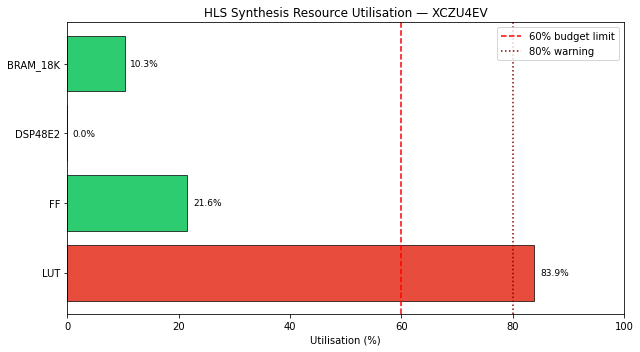

Saved: ../results/resource_utilisation.png

✓ Phase 1C complete. Next: Phase 2 — Vivado Block Design
  HLS IP export directory: /home/atw/Edge_AI_Acc/claude/EdgeAI-ZU4EV_Claude/notebooks/hls4ml_prj


In [9]:
if df_res['Used'].sum() > 0:
    fig, ax = plt.subplots(figsize=(9, 5))

    x    = np.arange(len(df_res))
    pcts = df_res['Utilisation_%'].tolist()
    cols = ['#e74c3c' if p > 80 else '#2ecc71' if p < 40 else '#f39c12' for p in pcts]

    bars = ax.barh(df_res['Resource'], pcts, color=cols, edgecolor='black', linewidth=0.7)
    ax.axvline(60, color='red',    linestyle='--', label='60% budget limit')
    ax.axvline(80, color='darkred',linestyle=':',  label='80% warning')
    ax.set_xlabel('Utilisation (%)')
    ax.set_title('HLS Synthesis Resource Utilisation — XCZU4EV')
    ax.legend()
    ax.set_xlim([0, 100])
    for bar, pct in zip(bars, pcts):
        ax.text(pct+1, bar.get_y()+bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../results/resource_utilisation.png', dpi=150)
    plt.show()
    print('Saved: ../results/resource_utilisation.png')
else:
    print('[INFO] Synthesis not yet run — skipping resource plot.')

print('\n✓ Phase 1C complete. Next: Phase 2 — Vivado Block Design')
print(f'  HLS IP export directory: {os.path.abspath(HLS_OUTPUT_DIR)}')